# Скрейпинг рейтингов фильмов и NLP регрессия

В этом блокноте собирается собственный датасет фильмов с yts.mx. Извлекаются названия, описание, жанры и числовые рейтинги. Затем тексты преобразуются в признаки TF IDF, и обучаются модели линейной регрессии для предсказания рейтинга по описанию. В работе учтены вежливый режим запросов, повторы при ошибках, а также несколько стратегий извлечения жанров.

## План
1. Парсинг фильмов с вежливой задержкой и повторами при ошибках
2. Сохранение и первичная проверка датасета
3. Разделение на train и test
4. TF IDF преобразование: униграммы и биграммы, английские стоп слова, min_df и max_df, без нормировки признаков
5. Линейная регрессия и Ridge с подбором параметра регуляризации
6. Оценка качества RMSE и R2
7. Визуализация топ 50 признаков
8. Выводы

In [8]:
!pip -q install requests beautifulsoup4 lxml pandas scikit-learn matplotlib tqdm

In [9]:
import time
import json
import re
from typing import List, Dict, Optional
from urllib.parse import urljoin

import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

In [10]:
BASE = "https://yts.mx/"
BROWSE_TEMPLATE = urljoin(BASE, "browse-movies?page={page}")

# Параметры вежливого парсинга
REQUEST_DELAY_SEC = 0.8
TIMEOUT = 20
MAX_RETRIES = 3
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; DS-HW-MovieScraper/3.0)",
    "Accept-Language": "en-US,en;q=0.9"
}

# Ограничение числа страниц для демонстрации. Увеличьте при необходимости.
MAX_PAGES = 25

In [11]:
def fetch(url: str) -> str:
    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            time.sleep(REQUEST_DELAY_SEC)
            resp = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
            if resp.status_code in (429, 500, 502, 503, 504):
                raise requests.HTTPError(f"HTTP {resp.status_code}")
            resp.raise_for_status()
            return resp.text
        except Exception as e:
            last_err = e
            time.sleep(REQUEST_DELAY_SEC * attempt)
    raise RuntimeError(f"Не удалось получить {url}: {last_err}")

In [12]:
def parse_browse_page(html: str) -> List[str]:
    soup = BeautifulSoup(html, "lxml")
    links = []
    for a in soup.select("a.browse-movie-title"):
        href = a.get("href")
        if href:
            links.append(href)
    return links

def text_or_empty(el):
    return el.get_text(" ", strip=True) if el else ""

def extract_year(text: str) -> Optional[int]:
    m = re.search(r"(19|20)\d{2}", text)
    return int(m.group(0)) if m else None

def extract_rating_from_text(text: str) -> Optional[float]:
    m = re.search(r"IMDb[^\d]{0,30}(\d+(?:\.\d)?)\s*/\s*10", text, flags=re.I)
    if not m:
        m = re.search(r"Rating[^\d]{0,30}(\d+(?:\.\d)?)\s*/\s*10", text, flags=re.I)
    if not m:
        m = re.search(r"(\d+(?:\.\d)?)\s*/\s*10", text)
    if m:
        try:
            val = float(m.group(1))
            if 0 <= val <= 10:
                return val
        except:
            return None
    return None

def extract_genres(soup: BeautifulSoup) -> str:
    genres: List[str] = []

    # 1) JSON-LD
    for sc in soup.find_all("script", attrs={"type": "application/ld+json"}):
        try:
            data = json.loads(sc.string or "")
            items = data if isinstance(data, list) else [data]
            for d in items:
                if isinstance(d, dict) and "genre" in d:
                    g = d.get("genre")
                    if isinstance(g, list):
                        genres.extend([str(x).strip() for x in g if x])
                    elif isinstance(g, str):
                        genres.extend([x.strip() for x in g.split(",") if x.strip()])
        except Exception:
            pass

    # 2) itemprop=genre
    for el in soup.select("[itemprop=genre]"):
        t = text_or_empty(el)
        if t:
            genres.append(t)

    # 3) Ссылки по характерному пути
    for a in soup.select("a[href*='/browse-movies/']"):
        t = text_or_empty(a)
        if t and 2 <= len(t) <= 20 and all(ch.isalpha() or ch in "- &" for ch in t):
            genres.append(t)

    # 4) meta keywords
    meta_kw = soup.find("meta", attrs={"name": "keywords"})
    if meta_kw and meta_kw.get("content"):
        for tok in meta_kw["content"].split(","):
            t = tok.strip()
            if t and 2 <= len(t) <= 20 and all(ch.isalpha() or ch in "- &" for ch in t):
                genres.append(t)

    # Нормализация
    norm = []
    seen = set()
    for g in genres:
        g_clean = re.sub(r"\s+", " ", g).strip()
        if not g_clean:
            continue
        g_clean = g_clean.title()
        if g_clean not in seen:
            seen.add(g_clean)
            norm.append(g_clean)

    return ", ".join(norm)

In [13]:
def parse_movie_page(html: str, url: str) -> Dict:
    soup = BeautifulSoup(html, "lxml")

    title = text_or_empty(soup.select_one("h1")) or text_or_empty(soup.select_one(".hidden-xs h1"))
    year = extract_year(text_or_empty(soup.select_one(".year"))) or extract_year(text_or_empty(soup.find("h2", class_="subtitle")))

    desc = text_or_empty(soup.select_one("#synopsis")) or text_or_empty(soup.select_one(".synopsis"))
    if not desc:
        og_desc = soup.find("meta", attrs={"property": "og:description"})
        if og_desc and og_desc.get("content"):
            desc = og_desc["content"]
    if not desc:
        meta_desc = soup.find("meta", attrs={"name": "description"})
        if meta_desc and meta_desc.get("content"):
            desc = meta_desc["content"]

    genres = extract_genres(soup)

    page_text = soup.get_text(" ", strip=True)
    rating = extract_rating_from_text(page_text)

    return {
        "url": url,
        "title": title,
        "year": year,
        "rating": rating,
        "genres": genres,
        "description": desc
    }

In [14]:
all_rows = []
for page in range(1, (MAX_PAGES or 1000) + 1):
    browse_url = BROWSE_TEMPLATE.format(page=page)
    try:
        html = fetch(browse_url)
    except Exception as e:
        print(f"Ошибка запроса страницы каталога {browse_url}: {e}")
        break

    links = parse_browse_page(html)
    if not links:
        print("Похоже, выдача закончилась на странице", page)
        break

    for link in tqdm(links, desc=f"Страница {page}, фильмов", leave=False):
        try:
            detail_html = fetch(link)
            row = parse_movie_page(detail_html, link)
            all_rows.append(row)
        except Exception as e:
            print(f"Ошибка на карточке {link}: {e}")

df = pd.DataFrame(all_rows)
print("Собрано строк:", len(df))
df.head(5)

Собрано строк: 500


,url,title,year,rating,genres,description
0,https://yts.mx/movies/the-last-horror-movie-2003,The Last Horror Movie,None,5.5,"Psychopath, Serial Killer, Slasher, Found Footage, Julian Richards, Rita Davies, Brian Bowles, Philip Rosch, Ranjit ...",Plot summary A serial killer uses a horror video rental to lure his next victim. What begins as a teen slasher trans...
1,https://yts.mx/movies/the-last-keepers-2013,The Last Keepers,None,5.5,"Witch, Gallery, Culture Clash, Artist, Vanity Project, Woman Director, Maggie Greenwald, Jee Young Han, Olympia Duka...",Plot summary This romantic fantasy movie is about two people who are the last survivors of an ancient line of goddes...
2,https://yts.mx/movies/backlight-2010,Backlight,None,6.0,"Fernando Fragata, Skyler Day, Donovan Scott, Caitlin Carmichael, Joaquim De Almeida, Yts, Yify, Yts Yify, Yify Movie...",Plot summary Several characters who are each at critical stages of their lives are strangely impelled towards an unc...
3,https://yts.mx/movies/the-lost-bus-2025,The Lost Bus,None,7.3,"California, Fire, Bus, Bus Driver, Based On True Story, Yts, Yify, Yts Yify, Yify Movies, Yts Movies, Yts Torrents, ...",Plot summary A determined father risks everything to rescue a dedicated teacher and her students from a raging wildf...
4,https://yts.mx/movies/reel-injun-2009,Reel Injun,None,7.5,"Native American, Hollywood, Woman Director, American West, Far West, Jeremiah Hayes, Clint Eastwood, Graham Greene, ...","Plot summary The evolution of the depiction of the various Native American peoples in cinema, from the silent era to..."


In [15]:
df = df.dropna(subset=["rating"]).copy()
df["text"] = (df["title"].fillna("") + " " + df["description"].fillna("")).str.strip()
df = df[df["text"].str.len() > 0].copy()
df = df[(df["rating"] >= 0) & (df["rating"] <= 10)]
df = df.drop_duplicates(subset=["url"]).reset_index(drop=True)

print("Размерность после очистки:", df.shape)
df[["title","year","rating","genres"]].head(10)

Размерность после очистки: (484, 7)


,title,year,rating,genres
0,The Last Horror Movie,None,5.5,"Psychopath, Serial Killer, Slasher, Found Footage, Julian Richards, Rita Davies, Brian Bowles, Philip Rosch, Ranjit ..."
1,The Last Keepers,None,5.5,"Witch, Gallery, Culture Clash, Artist, Vanity Project, Woman Director, Maggie Greenwald, Jee Young Han, Olympia Duka..."
2,Backlight,None,6.0,"Fernando Fragata, Skyler Day, Donovan Scott, Caitlin Carmichael, Joaquim De Almeida, Yts, Yify, Yts Yify, Yify Movie..."
3,The Lost Bus,None,7.3,"California, Fire, Bus, Bus Driver, Based On True Story, Yts, Yify, Yts Yify, Yify Movies, Yts Movies, Yts Torrents, ..."
4,Reel Injun,None,7.5,"Native American, Hollywood, Woman Director, American West, Far West, Jeremiah Hayes, Clint Eastwood, Graham Greene, ..."
5,Grand Expectations,None,6.5,"Sylvain Desclous, Benjamin Lavernhe, Rebecca Marder, Cédric Appietto, Eric Soubelet, Yts, Yify, Yts Yify, Yify Movie..."
6,Rockstar Duki desde el fin del mundo,None,7.0,"Music Documentary, Alejandro Hartmann, Duki, Yts, Yify, Yts Yify, Yify Movies, Yts Movies, Yts Torrents, Yify Torrents"
7,William Tell,None,5.7,"Switzerland, Rape And Murder, Apple, Medieval, Crossbow, Nick Hamm, Golshifteh Farahani, Ben Kingsley, Claes Bang, J..."
8,Wrapped Up in Christmas,None,6.0,"Christmas, Yts, Yify, Yts Yify, Yify Movies, Yts Movies, Yts Torrents, Yify Torrents"
9,Love Birds,None,6.1,"Paul Murphy, Wesley Dowdell, Bryan Brown, Faye Smythe, Emily Barclay, Yts, Yify, Yts Yify, Yify Movies, Yts Movies, ..."


In [16]:
X = df["text"].values
y = df["rating"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 363 Test: 121


In [19]:
df["rating"].describe()
df["text"].str.len().describe()

,text
count,484.000000
mean,280.772727
std,146.595265
min,21.000000
25%,182.750000
50%,243.500000
75%,334.500000
max,960.000000


In [18]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    stop_words="english",
    min_df=5,
    max_df=0.85,
    norm=None
)

pipe_no_reg = Pipeline([
    ("tfidf", tfidf),
    ("reg", LinearRegression())
])

pipe_no_reg.fit(X_train, y_train)
pred_no = pipe_no_reg.predict(X_test)

mse_no = mean_squared_error(y_test, pred_no)
rmse_no = mse_no ** 0.5
r2_no = r2_score(y_test, pred_no)

print("Без регуляризации")
print("RMSE:", rmse_no)
print("R2:", r2_no)

Без регуляризации
RMSE: 4.225425405150416
R2: -6.573940007625879


In [23]:
pipe_ridge = Pipeline([
    ("tfidf", tfidf),
    ("reg", Ridge(random_state=42))
])

param_grid = {
    "reg__alpha": [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
}

grid = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
pred_ridge = best_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, pred_ridge)
rmse_ridge = mse_ridge ** 0.5
r2_ridge = r2_score(y_test, pred_ridge)

print("С регуляризацией")
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
С регуляризацией
RMSE: 1.559153053651172
R2: -0.03123698803588515


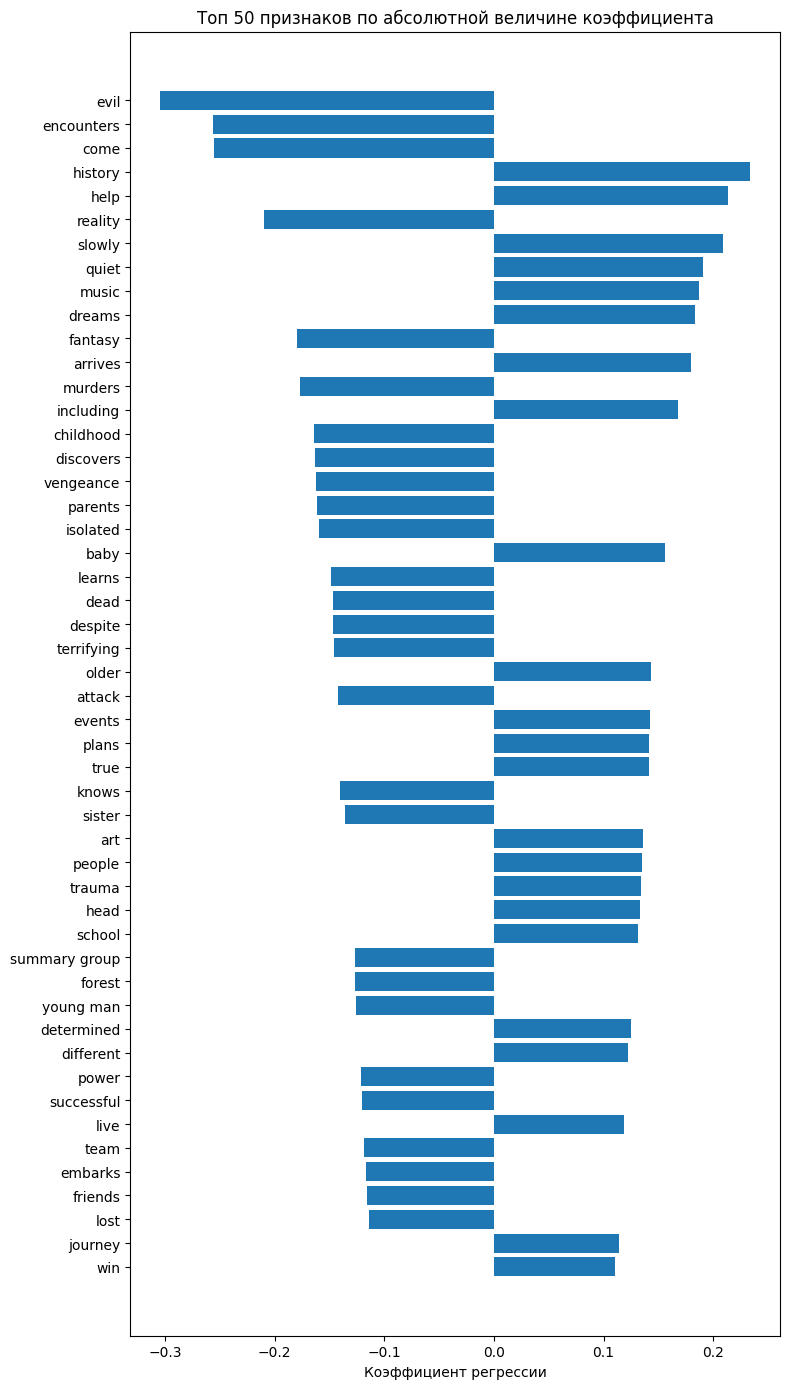

In [22]:
vect = best_model.named_steps["tfidf"]
reg = best_model.named_steps["reg"]

feature_names = np.array(vect.get_feature_names_out())
coefs = reg.coef_.ravel()

abs_idx = np.argsort(np.abs(coefs))[-50:]
top_features = feature_names[abs_idx]
top_values = coefs[abs_idx]

order = np.argsort(np.abs(top_values))
top_features = top_features[order]
top_values = top_values[order]

plt.figure(figsize=(8, 14))
plt.barh(range(len(top_features)), top_values)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel("Коэффициент регрессии")
plt.title("Топ 50 признаков по абсолютной величине коэффициента")
plt.tight_layout()
plt.show()

In [24]:
df.to_csv("movies_yts_dataset.csv", index=False)
print("Датасет сохранен в файл movies_yts_dataset.csv")

Датасет сохранен в файл movies_yts_dataset.csv


## Выводы

1. Датасет фильмов собран с yts.mx. Источниками текстов выступают заголовки и краткие описания, целевая переменная представляет собой числовой рейтинг по шкале от 0 до 10.
2. Применено TF IDF преобразование с униграммами и биграммами, удалены английские стоп слова, заданы пороги min_df и max_df, нормировка признаков отключена.
3. Сравнены линейная регрессия без регуляризации и Ridge регрессия с настройкой параметра регуляризации по кросс проверке. Приведены метрики RMSE и R2 на тестовой выборке.

Качество по R2 плохое и с регуляризацией и без. С ridge - получше, но сильно далека от идеала. Причина в том, что описания плохо коррелируют с рейтингом - нужно больше признаков вытаскивать, чем просто текст с сюжетом. Ну и данных собрано очень мало, правда не думаю что с увеличением данных будет лучше.